# Titanic Survival Prediction using Machine Learning

## Project Overview

This project predicts whether a passenger survived the Titanic disaster using machine learning classification models.

### Objectives
- Perform data preprocessing
- Handle missing values
- Encode categorical variables
- Compare multiple ML algorithms
- Evaluate models using different metrics
- Analyze feature importance

### Technologies
- Python
- Pandas
- NumPy
- Scikit-Learn
- Matplotlib

In [46]:
import pandas as pd
import numpy as np

print("Everything works!")

Everything works!


In [47]:
df = pd.read_csv("titanic.csv")  # İlk 5 satırı tablo halinde görmek için

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [48]:
df.shape # satır ve sütun sayısını görcem

(891, 12)

In [49]:
df.info() # Hangi sütunların eksik veri içerdiğini görmek için

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [50]:
df["Sex"] = df["Sex"].map({  # Sex sütununu sayıya çevirmek için, artık male 0 female 1
    "male": 0,
    "female": 1
})

In [51]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


In [52]:
df["Age"] = df["Age"].fillna(  # Eksik yaşları doldurcaz ki boş değer olmasın
    df["Age"].median()
)

In [53]:
X = df[["Pclass", "Sex", "Age"]]  # x ve y olarak değerleri oluşturdum # Modelin kullanacağı özellikleri (features) X değişkenine atıyorum. Tahmin etmeye çalıştığım hedef değişkeni (Survived) ise y değişkenine atıyorum.

y = df["Survived"]

In [54]:
from sklearn.model_selection import train_test_split  # veriyi train ve test datası için ikiye böldüm

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
from sklearn.ensemble import RandomForestClassifier  # Model

model = RandomForestClassifier(
    random_state=42
)

In [56]:
model.fit(  # Modeli eğittim kısım, bu çalışınca model titanic verisini 'öğren'miş olacak
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [57]:
predictions = model.predict(  # Tahmin yapıp ilk tahminleri gördüğüm yer
    X_test
)

predictions[:10] # Model ilk 10 yolcu için öldü mü (0) yoksa hayatta mı (1) tahmini yapıyor

array([0, 0, 0, 1, 0, 0, 1, 0, 1, 1])

In [58]:
from sklearn.metrics import accuracy_score  # Accuracy için

accuracy = accuracy_score(
    y_test,
    predictions
)

print(accuracy)

0.7932960893854749


In [59]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [60]:
precision = precision_score(  # Precision için
    y_test,
    predictions
)

print("Precision:", precision)

Precision: 0.7761194029850746


In [61]:
recall = recall_score(  # Recall için
    y_test,
    predictions
)

print("Recall:", recall)

Recall: 0.7027027027027027


In [62]:
f1 = f1_score(  # F1 Score için
    y_test,
    predictions
)

print("F1 Score:", f1)

F1 Score: 0.7375886524822695


In [63]:
from sklearn.metrics import confusion_matrix  # Confusion Matrix yani TP TN FP FN tablosu

cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[90 15]
 [22 52]]


TN = 90   Gerçekten ölmüş 90 kişi var, model de öldüler demiş. DOĞRU
FP = 15   Kurtulmuş 15 kişi var ama model onlara öldü demiş. YANLIŞ
FN = 22   Ölmüş 22 kişi var ama model onlara kurtuldu demiş. YANLIŞ
TP = 52   Kurtulmuş 52 kişi var ve model de kurtuldular demiş. DOĞRU


In [64]:
df.columns  # Modeli geliştirmek için veri setindeki diğer sütunlara bakıyorum hangi özellikler işe yarar, gereksiz ya da yeni özellik olarak eklenmeli? onları çıkarcam

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [65]:
df["Embarked"] = df["Embarked"].fillna("S")  # Embarked sütunundaki eksik değerleri en yaygın liman olan "S" ile dolduruyorum. Daha sonra makine öğrenmesi algoritmalarının kullanabilmesi için kategorik değerleri (S, C, Q) sayısal değerlere dönüştürüyorum.

df["Embarked"] = df["Embarked"].map({
    "S": 0, # Southampton 1 oldu
    "C": 1, # Cherbourg 2 oldu
    "Q": 2  # Queenstown 3 oldu
})

In [ ]:
df["Fare"] = df["Fare"].fillna(  # Fare sütunundaki eksik değerleri sütunun medyan değeri ile dolduruyorum. Böylece model eğitim sırasında boş veri nedeniyle hata vermiyo
    df["Fare"].median()
)

In [ ]:
X = df[  # Bunlar da olsun dediğim featureları xe ekliyorum ve güncelledim x y'yi
    [
        "Pclass",
        "Sex",
        "Age",
        "Fare",
        "SibSp",
        "Parch",
        "Embarked"
    ]
]

y = df["Survived"]

| Metric    | İlk Model | Yeni Model |
| --------- | --------- | ---------- |
| Accuracy  | 79.33%    | **81.01%** |
| Precision | 77.61%    | **77.78%** |
| Recall    | 70.27%    | **75.68%** |
| F1 Score  | 73.76%    | **76.71%** |

Yeni featureları (Fare, SibSp, Parch ,Embarked) ekleyip x y'yi güncelledikten sonra değişen performans metriklerim. Artık model kurtulan insanların daha fazlasını tespit edebildi (recall)

Random Forest'ın içinde bir özellik var: Feature Importance, YANİ:

Model karar verirken hangi sütuna ne kadar önem verdi?

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

ValueError: All arrays must be of the same length

Sex 0.27 yani modelin verdiği kararların yaklaşık %27'si bu feature'dan etkileniyor. Titanic'te 'Women and children first' politikası uygulanmıştı. Bu yüzden kadınların kurtulma oranı erkeklerden çok daha yüksekti. Model bunu keşfetmiş yani

Fare 0.26 bilet ücreti arttıkça zenginlik de artıyor, e zenginler daha üst sınıflarda seyahat ederken cankurtaran botlarına erişimleri daha kolay. Bu yüzden fare güçlü çıkmış...

**Şu ana kadar random forest kullanmıştık, Ama bu en iyi seçenek mi onu kontrol edicez şimdi**

In [ ]:
from sklearn.tree import DecisionTreeClassifier  # Deney 1 - Decision Tree ile Karşılaştırıyorum
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7988826815642458


In [ ]:
from sklearn.svm import SVC  # Deney 2 - SVM ile Karşılaştırıyorum

svm_model = SVC()

svm_model.fit(
    X_train,
    y_train
)

svm_predictions = svm_model.predict(
    X_test
)

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.6536312849162011


In [ ]:
results = pd.DataFrame({  # Sonuçları tabloya dökme
    "Model": [
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        dt_accuracy,
        accuracy,
        svm_accuracy
    ]
})

results

,Model,Accuracy
0,Decision Tree,0.798883
1,Random Forest,0.810056
2,SVM,0.653631


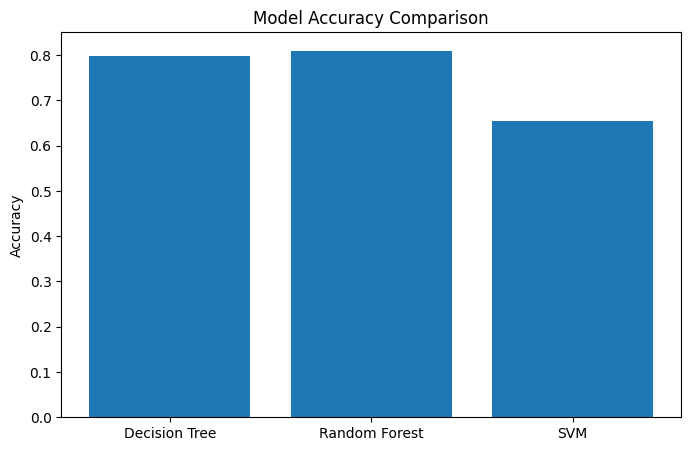

In [ ]:
import matplotlib.pyplot as plt  # Grafik çıkarma

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [ ]:
shallow_model = DecisionTreeClassifier(  # Overfitting deneyi için SIĞ ağaç
    max_depth=2,
    random_state=42
)

shallow_model.fit(
    X_train,
    y_train
)

print(
    accuracy_score(
        y_test,
        shallow_model.predict(X_test)
    )
)

0.7653631284916201


In [ ]:
deep_model = DecisionTreeClassifier(  # Overfitting deneyi için DERİN ağaç
    max_depth=20,
    random_state=42
)

deep_model.fit(
    X_train,
    y_train
)

print(
    accuracy_score(
        y_test,
        deep_model.predict(X_test)
    )
)

0.7988826815642458


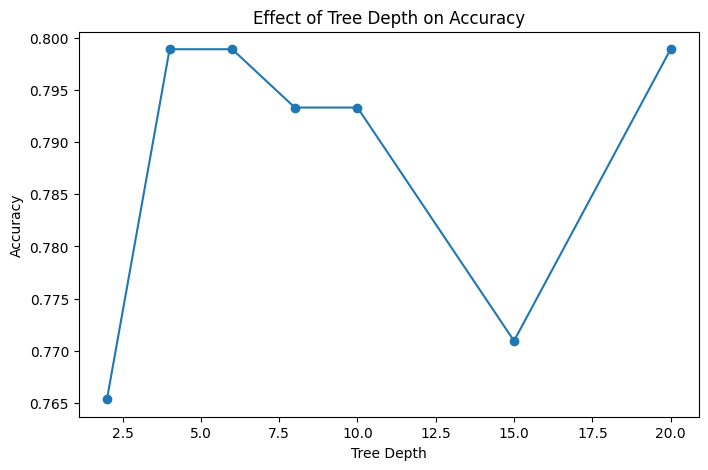

: 

In [ ]:
depths = [2, 4, 6, 8, 10, 15, 20]

scores = []

for d in depths:

    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    scores.append(
        accuracy_score(
            y_test,
            pred
        )
    )

plt.figure(figsize=(8,5))

plt.plot(
    depths,
    scores,
    marker="o"
)

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth on Accuracy")

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

NameError: name 'X_train' is not defined